<h1 style="font-family:verdana;"><center>Phân Khúc Khách Hàng Online Retail</center></h1>

<h3 style="font-family:verdana;"><center>sử dụng K-Means, DBSCAN và Agglomerative Clustering</center></h3>

>Tập dữ liệu **Online Retail** chứa các giao dịch mua hàng thực tế của một cửa hàng bán lẻ trực tuyến tại Anh trong giai đoạn 01/12/2010 – 09/12/2011. Mỗi dòng là một mặt hàng trong hóa đơn.

> **Mục tiêu:** Xây dựng đặc trưng **RFM (Recency – Frequency – Monetary)** từ dữ liệu giao dịch thô, sau đó áp dụng ba thuật toán phân cụm để phân khúc khách hàng một cách hiệu quả.

# 1. Nhập Thư Viện

In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", lambda x: "%.2f" % x)
print("Thư viện đã sẵn sàng!")

Thư viện đã sẵn sàng!


# 2. Tải & Khám Phá Dữ Liệu Thô

File Excel có 1 sheet duy nhất chứa toàn bộ dữ liệu giao dịch.

In [229]:
PATH = r"C:\Users\khact\Desktop\ML\BTL\papers\method\Customer_Classification\Online Retail.xlsx"

df = pd.read_excel(PATH, sheet_name="Online Retail")

print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [230]:
print("Thông tin tổng quan:")
df.info()
print("\nThống kê mô tả:")
df.describe()

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB

Thống kê mô tả:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [231]:
print("Giá trị null theo cột:")
print(df.isnull().sum())
print(f"\nTỷ lệ null CustomerID: {df['CustomerID'].isnull().mean()*100:.1f}%")

Giá trị null theo cột:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Tỷ lệ null CustomerID: 24.9%


# 3. Tiền Xử Lý Dữ Liệu

Các bước làm sạch:
1. Loại bỏ dòng không có `CustomerID`
2. Loại bỏ hóa đơn bị hủy (InvoiceNo bắt đầu bằng chữ "C")
3. Loại bỏ `Quantity <= 0` và `UnitPrice <= 0`
4. Loại bỏ mã hàng không hợp lệ (StockCode thuần số hoặc mã đặc biệt)

In [232]:
df_clean = df.copy()

# 1. Bỏ dòng không có CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# 2. Bỏ hóa đơn hủy
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# 3. Bỏ số lượng và giá không hợp lệ
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

# 4. Tính doanh thu từng dòng
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Sau khi làm sạch:", df_clean.shape)
print(f"Số khách hàng: {df_clean['CustomerID'].nunique()}")
print(f"Khoảng thời gian: {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
df_clean.head()

Sau khi làm sạch: (397884, 9)
Số khách hàng: 4338
Khoảng thời gian: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3.1 Xây Dựng Đặc Trưng RFM

| Đặc trưng | Ý nghĩa |
|-----------|----------|
| **Recency (R)** | Số ngày kể từ lần mua cuối cùng — càng nhỏ càng tốt |
| **Frequency (F)** | Số hóa đơn khác nhau — càng nhiều càng tốt |
| **Monetary (M)** | Tổng doanh thu — càng lớn càng tốt |

In [233]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("InvoiceNo",   "nunique"),
    Monetary  = ("Revenue",     "sum")
).reset_index()

print("RFM shape:", rfm.shape)
print("\nThống kê RFM:")
rfm.describe()

RFM shape: (4338, 4)

Thống kê RFM:


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.49
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


# 4. Chuẩn Hóa Dữ Liệu

RFM có độ lệch (skew) lớn — đặc biệt Monetary. Ta chuẩn hóa theo từng thuật toán, không log:
- **K-Means & Agglomerative**: dùng `X_mm` = MinMaxScaler trên RFM gốc.
- **DBSCAN**: dùng `X_std` = StandardScaler trên RFM gốc.

X_mm  (MinMaxScaler):   shape=(4338, 3)   -- dung cho K-Means & Agglomerative
X_std (StandardScaler): shape=(4338, 3)   -- dung cho DBSCAN va EDA


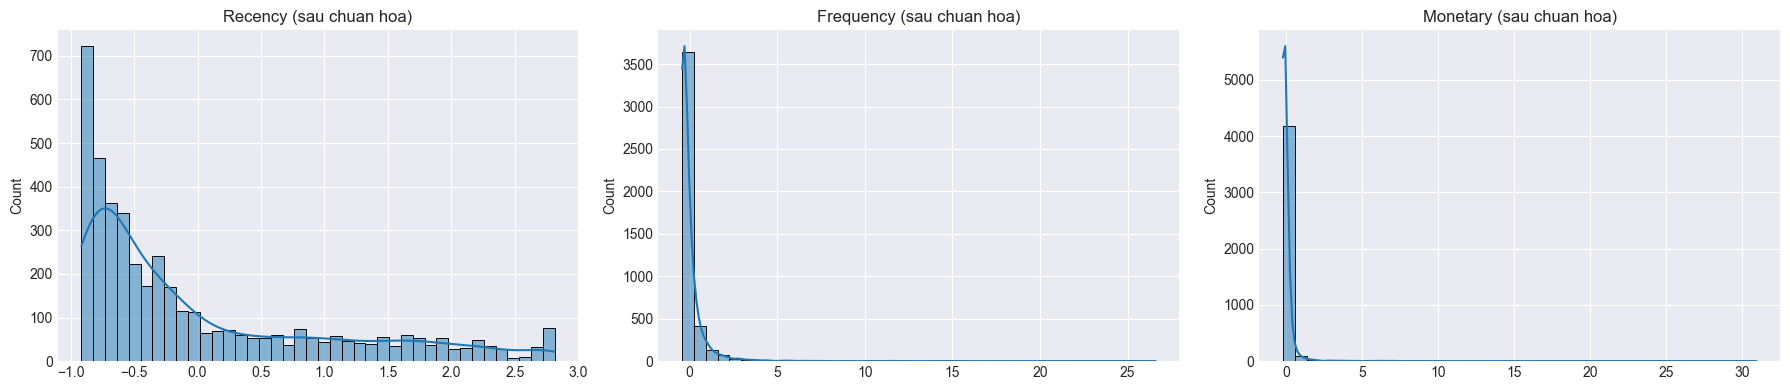

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler tren RFM goc -- dung cho K-Means & Agglomerative
mm_scaler = MinMaxScaler()
X_mm = mm_scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# StandardScaler tren RFM goc - dung cho DBSCAN 
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

print(f"X_mm  (MinMaxScaler):   shape={X_mm.shape}   -- dung cho K-Means & Agglomerative")
print(f"X_std (StandardScaler): shape={X_std.shape}   -- dung cho DBSCAN va EDA")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, i in zip(axes, ["Recency","Frequency","Monetary"], range(3)):
    sns.histplot(X_std[:, i], bins=40, ax=ax, kde=True)
    ax.set_title(f"{col} (sau chuan hoa)")
plt.tight_layout()
plt.show()


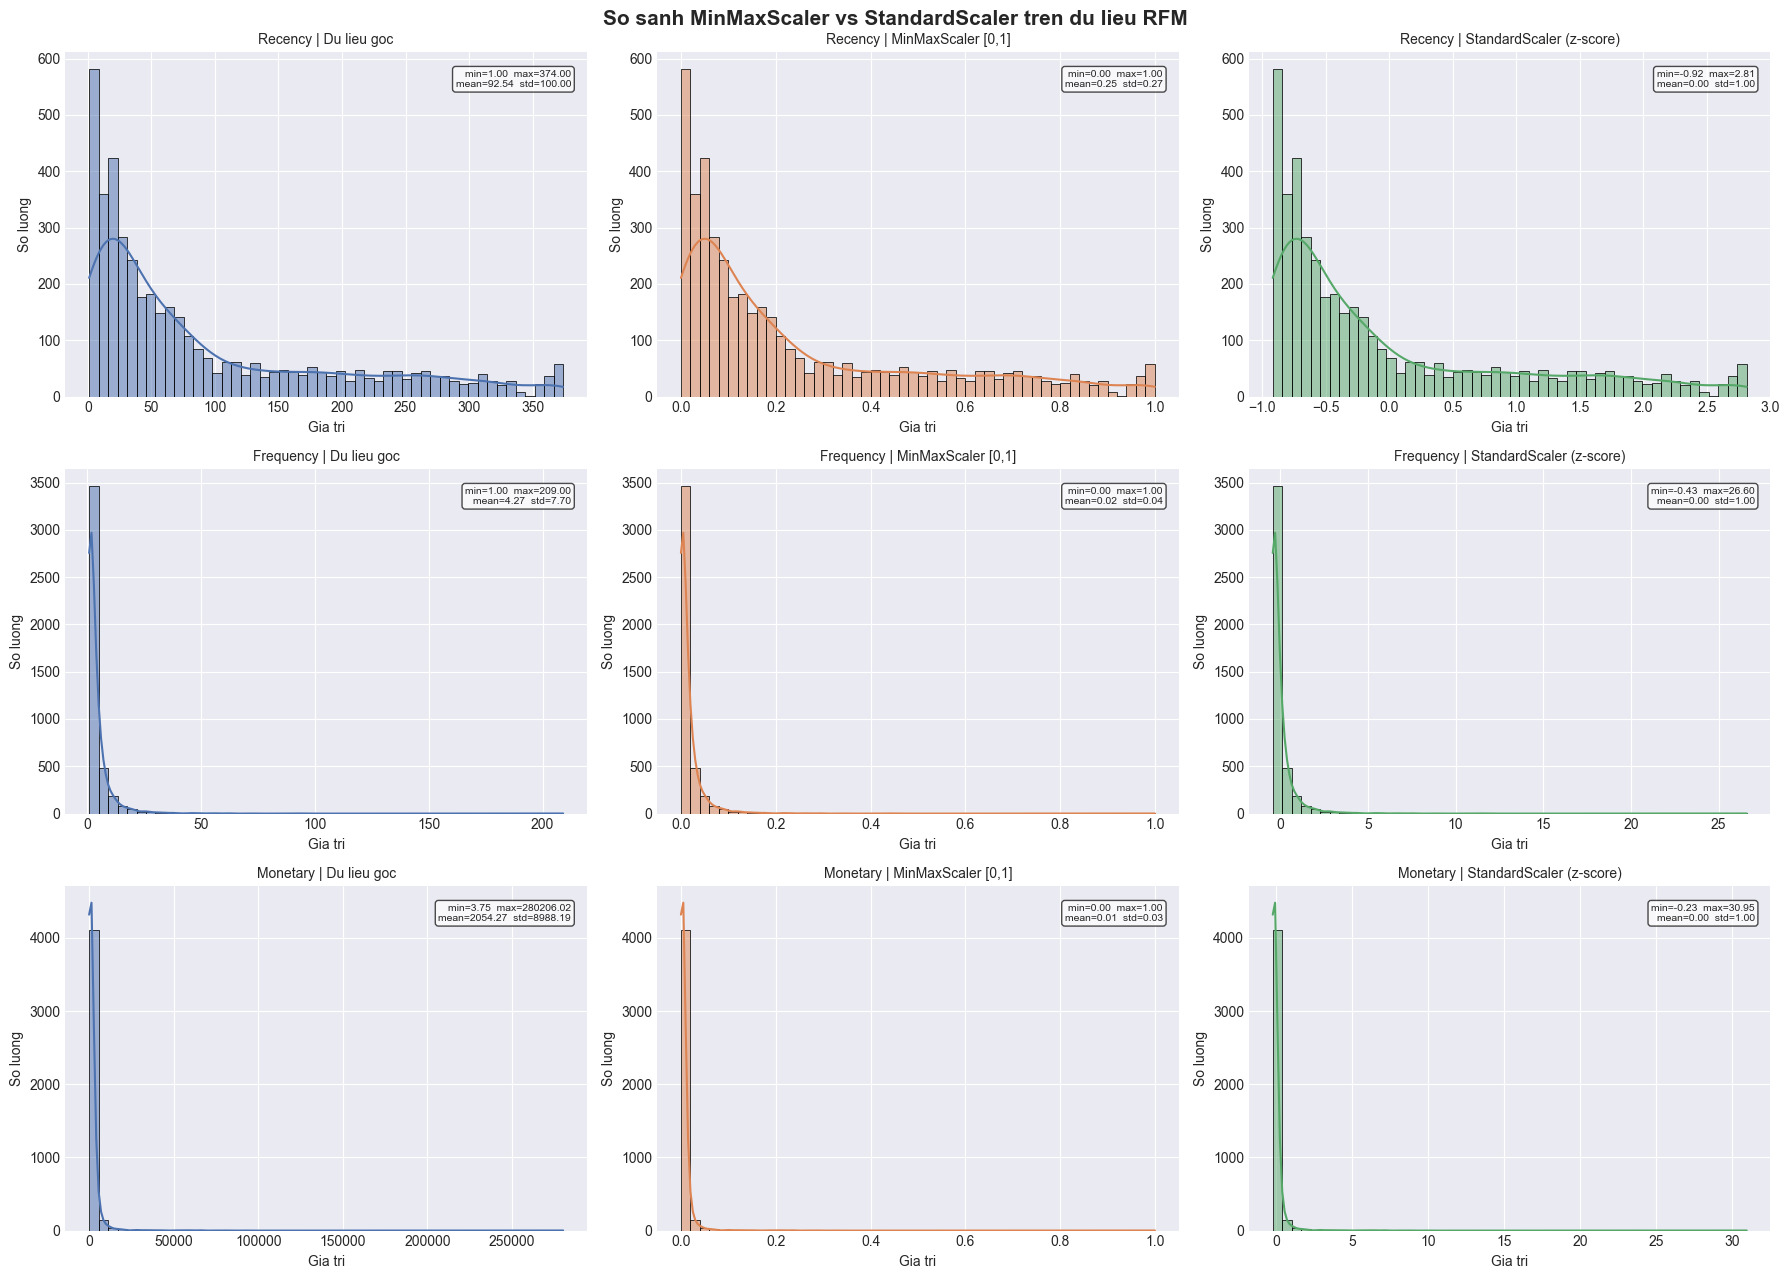

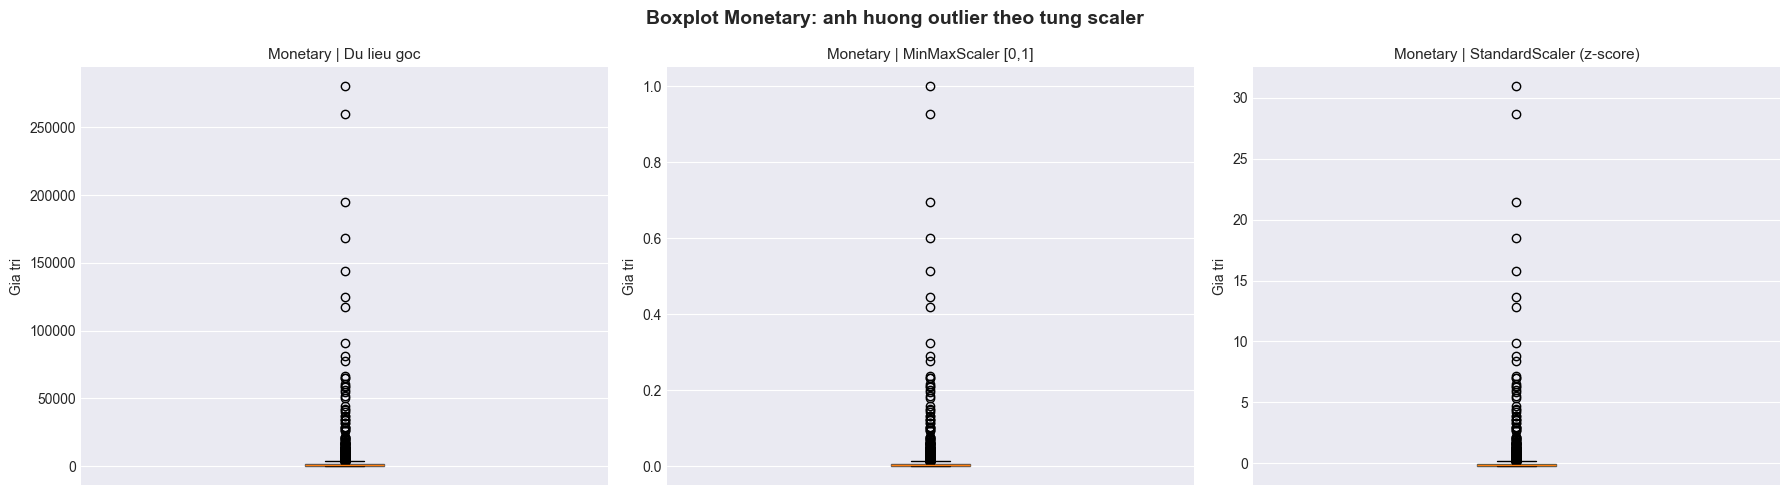

In [235]:
cols = ["Recency", "Frequency", "Monetary"]
data_versions = [
    rfm[["Recency","Frequency","Monetary"]].values,
    X_mm,
    X_std,
]
col_titles = ["Du lieu goc", "MinMaxScaler [0,1]", "StandardScaler (z-score)"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle("So sanh MinMaxScaler vs StandardScaler tren du lieu RFM", fontsize=15, fontweight="bold")

for row, col_name in enumerate(cols):
    for col_idx, (data, title, color) in enumerate(zip(data_versions, col_titles, colors)):
        ax = axes[row, col_idx]
        values = data[:, row]
        sns.histplot(values, bins=50, ax=ax, kde=True, color=color)
        ax.set_title(f"{col_name} | {title}", fontsize=10)
        ax.set_xlabel("Gia tri")
        ax.set_ylabel("So luong")
        line1 = "min={:.2f}  max={:.2f}".format(values.min(), values.max())
        line2 = "mean={:.2f}  std={:.2f}".format(values.mean(), values.std())
        ax.text(0.97, 0.95, line1 + chr(10) + line2, transform=ax.transAxes,
                fontsize=7.5, va="top", ha="right",
                bbox=dict(boxstyle="round", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Boxplot Monetary: anh huong outlier theo tung scaler", fontsize=14, fontweight="bold")

for ax, (data, title, color) in zip(axes2, zip(data_versions, col_titles, colors)):
    ax.boxplot(data[:, 2], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title("Monetary | " + title, fontsize=11)
    ax.set_ylabel("Gia tri")
    ax.set_xticks([])

plt.tight_layout()
plt.show()


# 5. Trực Quan Hóa Dữ Liệu (EDA)

## 5.1 Phân phối RFM

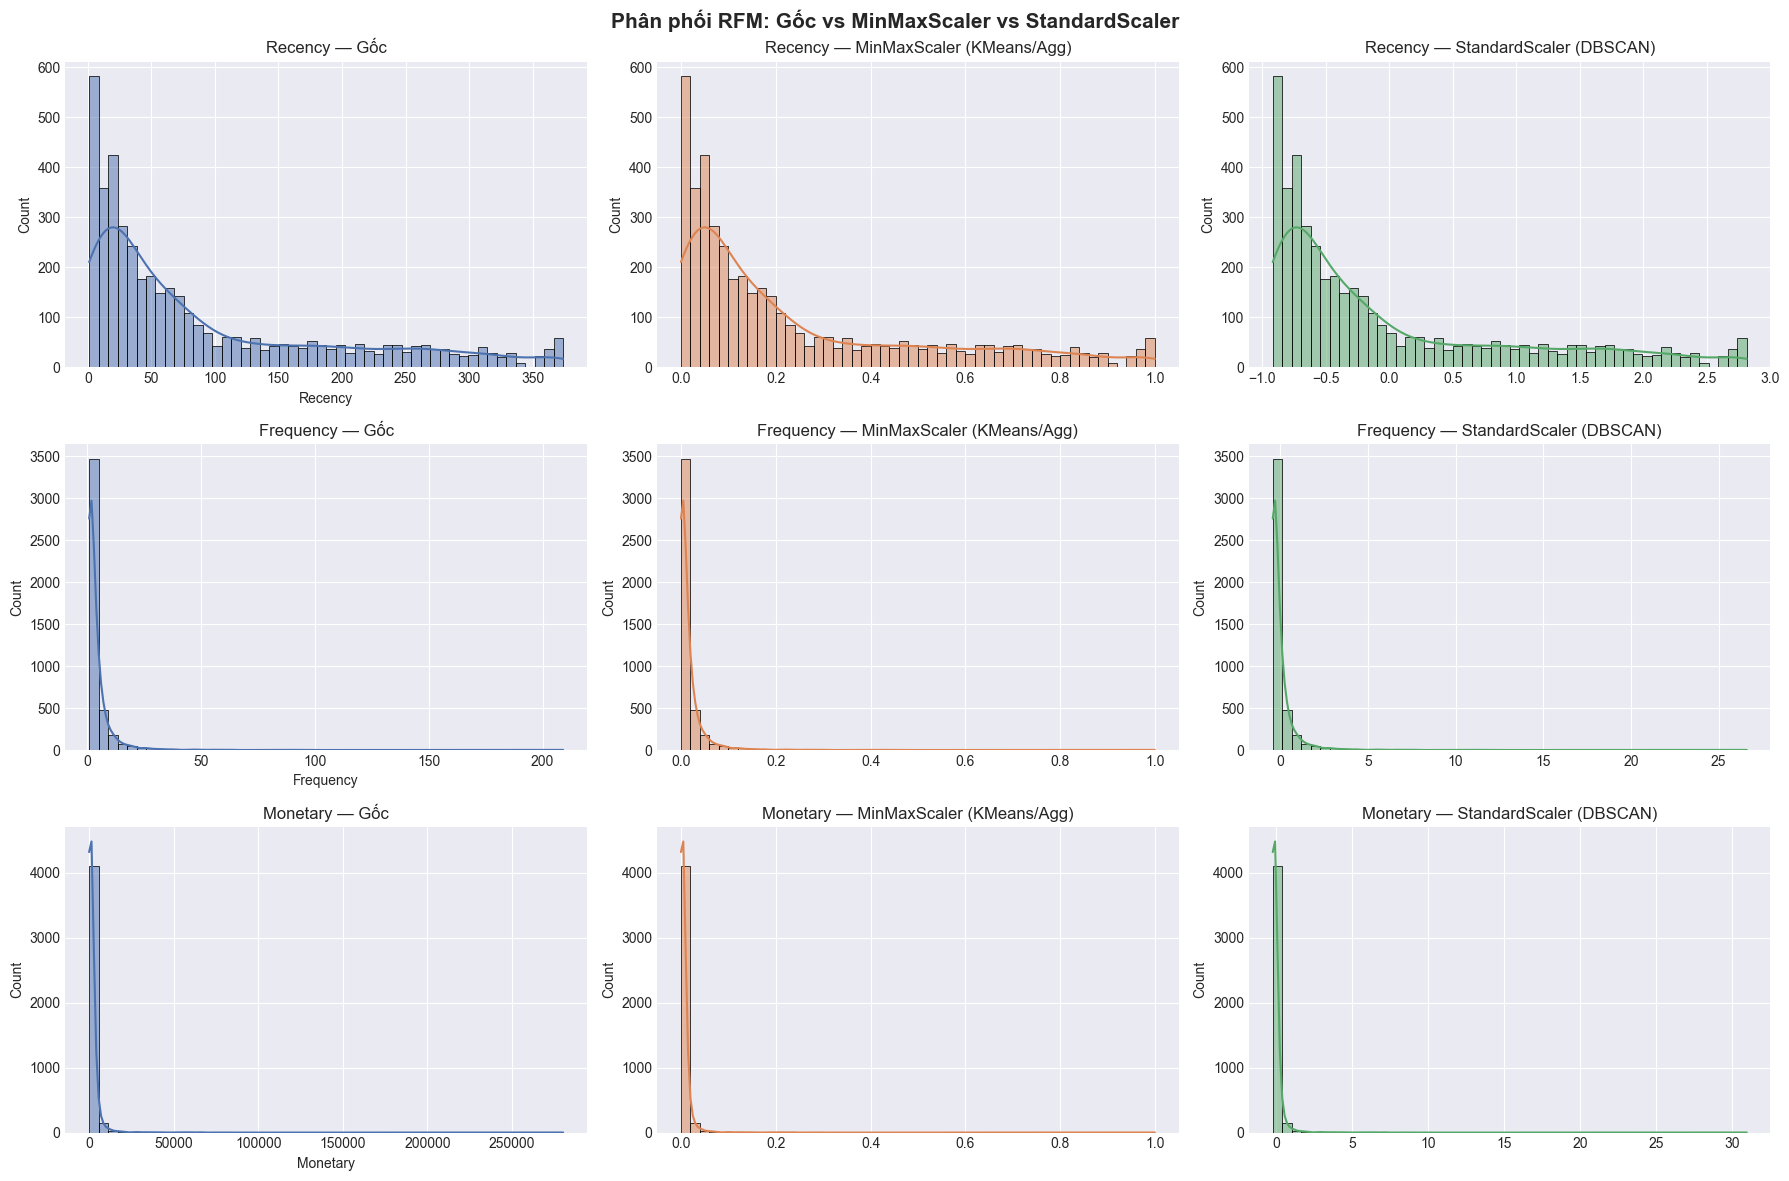

In [236]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    # Cột 1: dữ liệu gốc
    sns.histplot(rfm[col], bins=50, ax=axes[i, 0], kde=True, color="#4C72B0")
    axes[i, 0].set_title(f"{col} — Gốc", fontsize=12)

    # Cột 2: sau MinMaxScaler -- dùng cho K-Means & Agglomerative
    sns.histplot(X_mm[:, i], bins=50, ax=axes[i, 1], kde=True, color="#DD8452")
    axes[i, 1].set_title(f"{col} — MinMaxScaler (KMeans/Agg)", fontsize=12)

    # Cột 3: sau StandardScaler -- dùng cho DBSCAN
    sns.histplot(X_std[:, i], bins=50, ax=axes[i, 2], kde=True, color="#55A868")
    axes[i, 2].set_title(f"{col} — StandardScaler (DBSCAN)", fontsize=12)

fig.suptitle("Phân phối RFM: Gốc vs MinMaxScaler vs StandardScaler", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 5.2 Boxplot phát hiện ngoại lệ

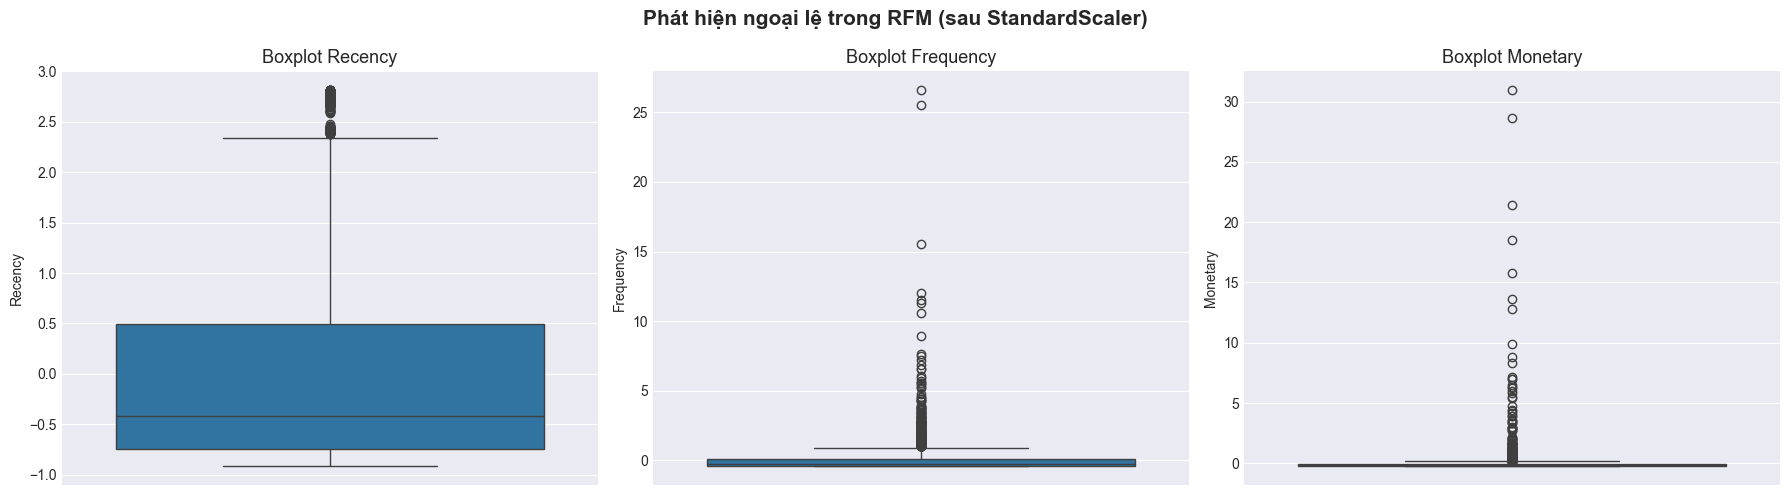

In [237]:
X_df = pd.DataFrame(X_std, columns=["Recency", "Frequency", "Monetary"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(y=X_df[col], ax=ax)
    ax.set_title(f"Boxplot {col}", fontsize=13)

plt.suptitle("Phát hiện ngoại lệ trong RFM (sau StandardScaler)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 5.3 Scatter plot giữa các cặp RFM

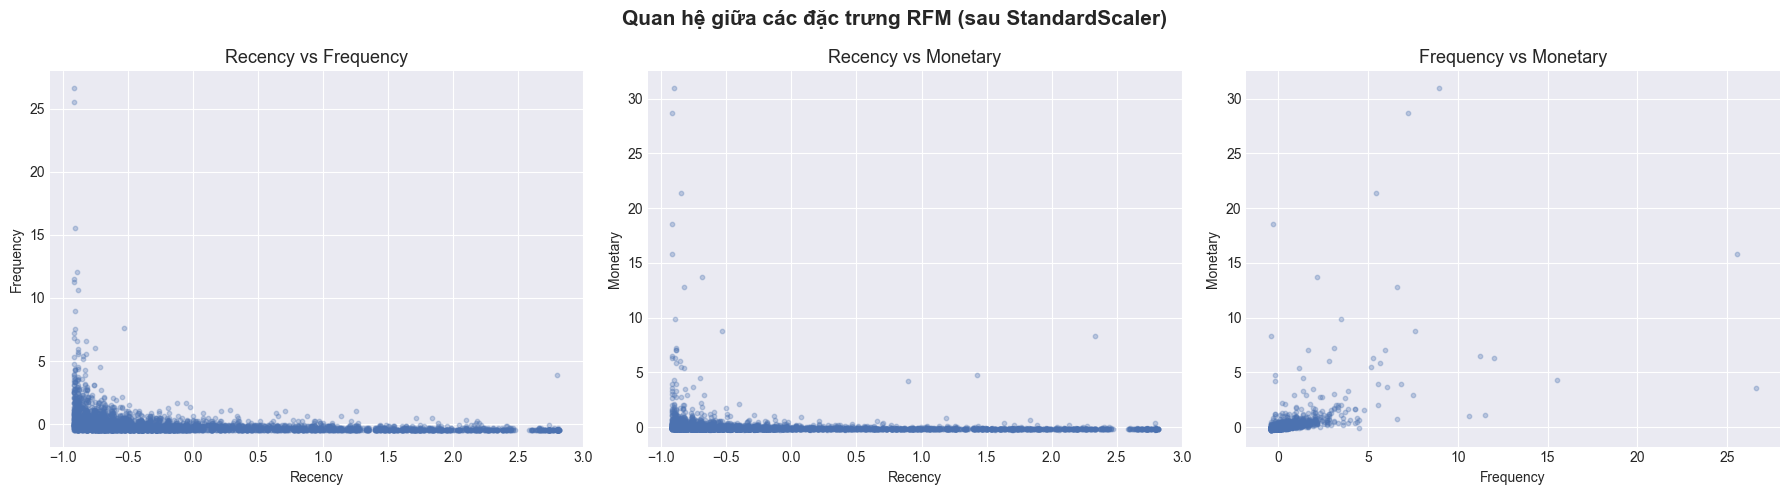

In [238]:
X_df = pd.DataFrame(X_std, columns=["Recency", "Frequency", "Monetary"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [("Recency", "Frequency"), ("Recency", "Monetary"), ("Frequency", "Monetary")]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(X_df[x], X_df[y], alpha=0.3, s=10, color="#4C72B0")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}", fontsize=13)

plt.suptitle("Quan hệ giữa các đặc trưng RFM (sau StandardScaler)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 5.4 Ma trận tương quan

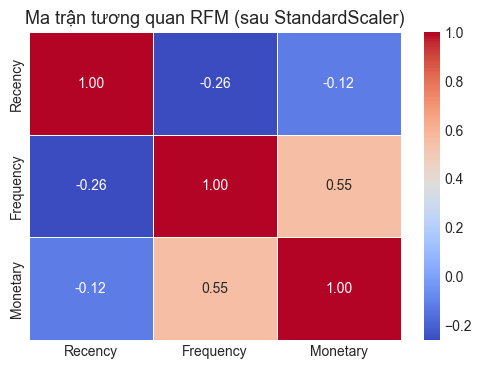

In [239]:
X_df = pd.DataFrame(X_std, columns=["Recency", "Frequency", "Monetary"])

plt.figure(figsize=(6, 4))
sns.heatmap(X_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Ma trận tương quan RFM (sau StandardScaler)", fontsize=13)
plt.show()


## 5.5 Top 10 quốc gia theo doanh thu

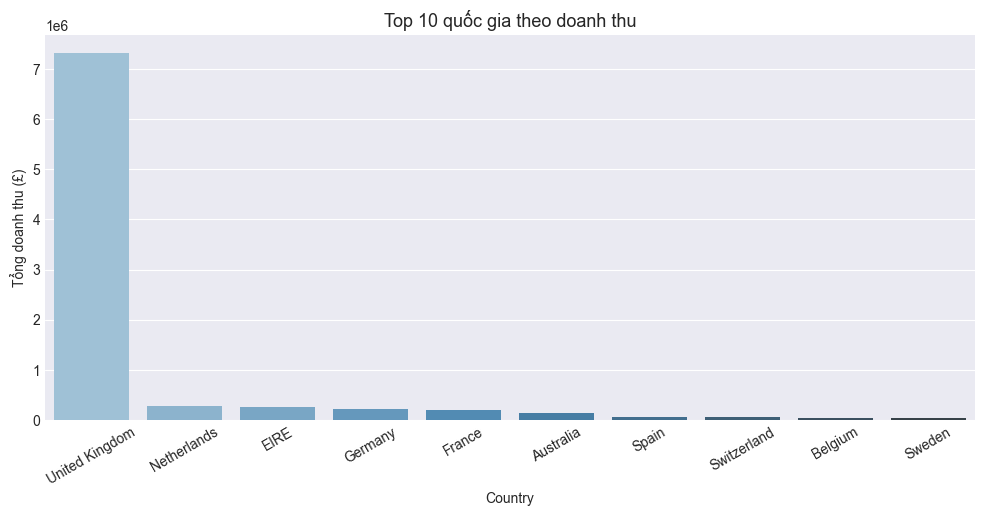

In [240]:
top_countries = df_clean.groupby("Country")["Revenue"].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x="Country", y="Revenue", palette="Blues_d")
plt.title("Top 10 quốc gia theo doanh thu", fontsize=13)
plt.xticks(rotation=30)
plt.ylabel("Tổng doanh thu (£)")
plt.show()

## 5.6 Doanh thu theo tháng

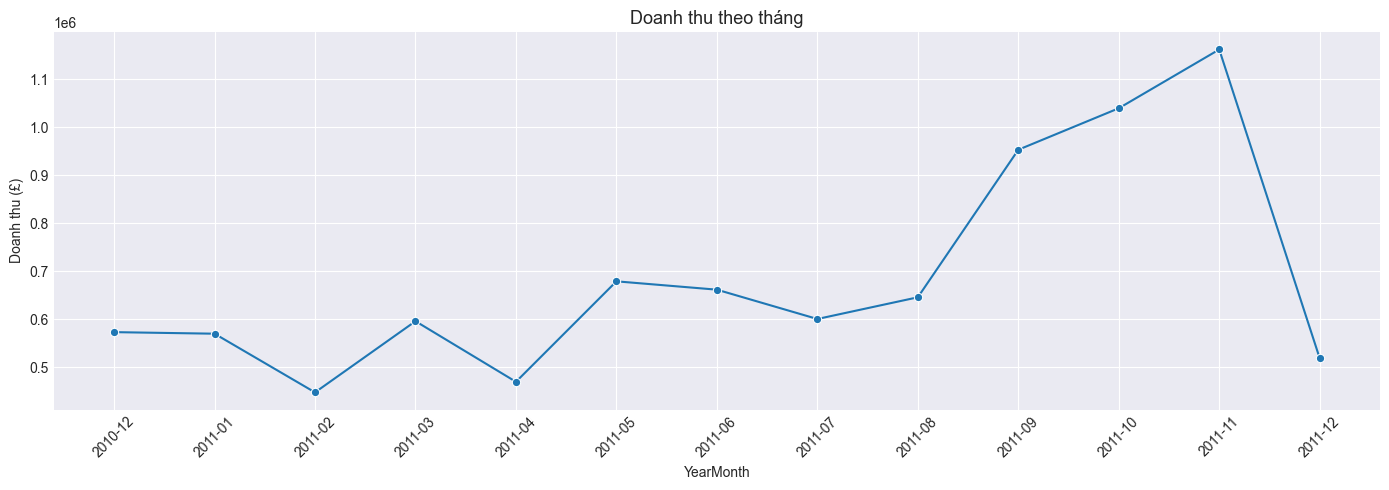

In [241]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")
monthly = df_clean.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x="YearMonth", y="Revenue", marker="o")
plt.title("Doanh thu theo tháng", fontsize=13)
plt.xticks(rotation=45)
plt.ylabel("Doanh thu (£)")
plt.tight_layout()
plt.show()

# 6. Các Hàm Đánh Giá Phân Cụm

In [242]:
PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
]

def auto_name_clusters(rfm_df, cluster_col):
    """
    Đặt tên cụm dựa trên ranking tổng hợp RFM (R thấp, F cao, M cao = tốt hơn).
    Số nhãn khả dụng phụ thuộc số cụm hợp lệ (không tính nhiễu) mà thuật toán tự tìm ra,
    nên nhãn chỉ mang ý nghĩa tương đối GIỮA CÁC CỤM CỦA CÙNG một thuật toán — không nên
    so sánh trực tiếp nhãn giữa hai thuật toán khác nhau (vd cụm "Khách ít hoạt động" của
    Agglomerative K=2 và cụm "Khách rời bỏ" của K-Means K=3 có thể trỏ tới nhóm khách hàng
    có chỉ số RFM gần giống nhau, khác biệt chỉ vì số cụm bị chia khác nhau).
    """
    valid = rfm_df[rfm_df[cluster_col] != -1].copy()
    means = valid.groupby(cluster_col)[["Recency", "Frequency", "Monetary"]].mean()
    norm = (means - means.min()) / (means.max() - means.min() + 1e-9)
    means["_score"] = -norm["Recency"] + norm["Frequency"] + norm["Monetary"]
    ranked = means["_score"].rank(ascending=False).astype(int)
    n = len(means)
    label_pool = {
        4: ["Khách VIP", "Khách tiềm năng", "Khách không hoạt động", "Khách rời bỏ"],
        3: ["Khách VIP", "Khách tiềm năng", "Khách rời bỏ"],
        2: ["Khách hoạt động", "Khách ít hoạt động"],
    }
    labels = label_pool.get(n, [f"Phân khúc {i+1}" for i in range(n)])
    name_map = {int(cid): labels[rank - 1] for cid, rank in ranked.items()}

    if -1 in rfm_df[cluster_col].unique():
        # "Nhiễu" (DBSCAN) không đồng nghĩa "khách xấu" -- so sánh vị trí điểm RFM tổng hợp
        # của nhiễu với dải điểm của các cụm hợp lệ để đặt tên đúng bản chất dữ liệu.
        rfm_min = means[["Recency", "Frequency", "Monetary"]].min()
        rfm_max = means[["Recency", "Frequency", "Monetary"]].max()
        noise_mean = rfm_df.loc[rfm_df[cluster_col] == -1, ["Recency", "Frequency", "Monetary"]].mean()
        noise_norm = (noise_mean - rfm_min) / (rfm_max - rfm_min + 1e-9)
        noise_score = -noise_norm["Recency"] + noise_norm["Frequency"] + noise_norm["Monetary"]
        if noise_score > means["_score"].max():
            name_map[-1] = "Ngoại lệ (chi tiêu vượt trội)"
        elif noise_score < means["_score"].min():
            name_map[-1] = "Ngoại lệ (gần như không hoạt động)"
        else:
            name_map[-1] = "Ngoại lệ"
    return name_map


def plot_elbow_silhouette(X, k_range=range(2, 11)):
    sse, sil = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
        km.fit(X)
        sse.append(km.inertia_)
        sil.append(silhouette_score(X, km.labels_))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(list(k_range), sse, "bo-")
    ax1.set_title("Elbow Method"); ax1.set_xlabel("Số cụm K"); ax1.set_ylabel("SSE (Inertia)")
    ax2.plot(list(k_range), sil, "ro-")
    ax2.set_title("Silhouette Score"); ax2.set_xlabel("Số cụm K"); ax2.set_ylabel("Silhouette Score")
    plt.suptitle("Lựa chọn số cụm K tối ưu", fontsize=14, fontweight="bold")
    plt.show()
    return sse, sil


def print_scores(labels, X, name):
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]
    X_valid = X[valid_mask]
    n_clusters = len(set(valid_labels))
    if n_clusters < 2:
        print(f"[{name}] Không đủ cụm để đánh giá.")
        return
    sil = silhouette_score(X_valid, valid_labels)
    db  = davies_bouldin_score(X_valid, valid_labels)
    print(f"[{name}] Số cụm: {n_clusters} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")


def plot_silhouette(X, labels, title):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    sil_avg = silhouette_score(X, labels)
    sample_sil = silhouette_samples(X, labels)
    y_lower = 10
    for i in sorted(set(labels)):
        if i == -1: continue
        vals = sample_sil[labels == i]
        vals.sort()
        y_upper = y_lower + len(vals)
        color = cm.tab10(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * len(vals), str(i))
        y_lower = y_upper + 10
    ax1.axvline(x=sil_avg, color="red", linestyle="--")
    ax1.set_title("Biểu đồ Silhouette"); ax1.set_xlabel("Hệ số Silhouette"); ax1.set_ylabel("Nhãn cụm")
    ax1.set_yticks([])
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    scatter = ax2.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
    ax2.set_title("Trực quan hóa cụm (PCA 2D)"); ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
    plt.colorbar(scatter, ax=ax2)
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.show()


def plot_rfm_clusters(rfm_df, labels, title):
    rfm_plot = rfm_df[["Recency","Frequency","Monetary"]].copy()
    rfm_plot["Cluster"] = labels
    rfm_plot = rfm_plot[rfm_plot["Cluster"] != -1]
    means = rfm_plot.groupby("Cluster").mean()
    means_norm = (means - means.min()) / (means.max() - means.min())
    means_norm.T.plot(kind="bar", figsize=(10, 5), colormap="tab10")
    plt.title(f"Đặc trưng trung bình RFM theo cụm — {title}", fontsize=13)
    plt.ylabel("Giá trị chuẩn hóa (0-1)")
    plt.xticks(rotation=0)
    plt.legend(title="Cụm", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
    return means


print("Các hàm tiện ích đã được định nghĩa!")


Các hàm tiện ích đã được định nghĩa!


# 7. Phân Cụm K-Means

**K-Means** là thuật toán phân cụm dựa trên tâm cụm (centroid-based). Thuật toán lặp lại hai bước: gán mỗi điểm vào cụm gần nhất, rồi cập nhật lại tâm cụm.

**Bước 1:** Dùng Elbow Method và Silhouette Score để chọn K tối ưu.

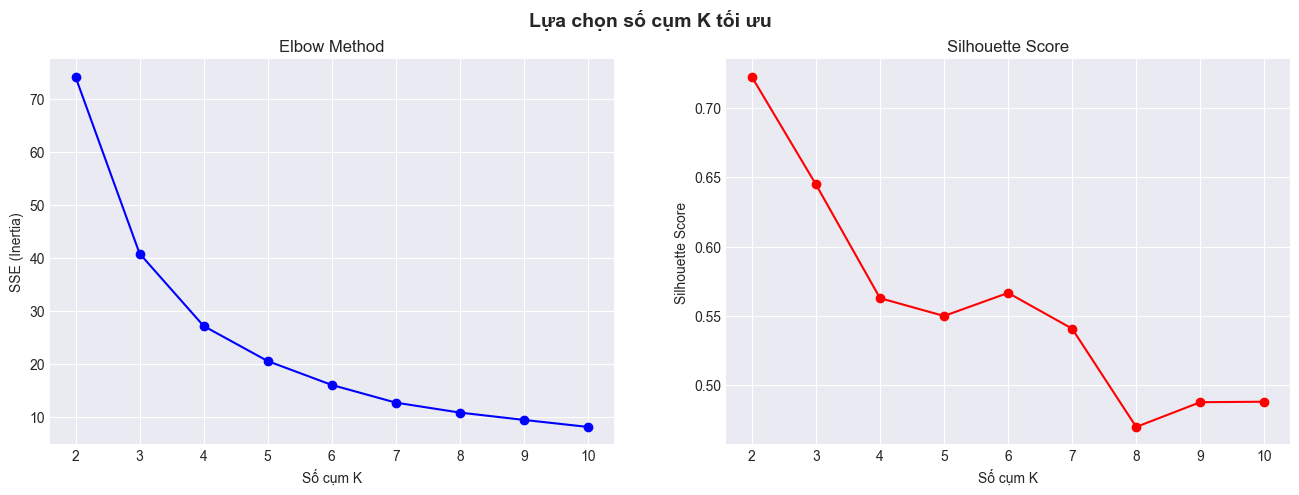

Silhouette Score theo từng K:
  K=2: 0.7225
  K=3: 0.6448
  K=4: 0.5628
  K=5: 0.5499
  K=6: 0.5666
  K=7: 0.5408
  K=8: 0.4699
  K=9: 0.4877
  K=10: 0.4881


In [243]:
sse, sil = plot_elbow_silhouette(X_mm)

k_range = range(2, 11)
print("Silhouette Score theo từng K:")
for k, s in zip(k_range, sil):
    print(f"  K={k}: {s:.4f}")


**Bước 2:** Huấn luyện K-Means với K tối ưu và đánh giá.

In [244]:
k_range = range(2, 11)
sse_arr = np.array(sse)

# Elbow method: tìm điểm gãy bằng đạo hàm bậc 2 của SSE (điểm cong nhiều nhất)
elbow_idx = int(np.argmax(np.diff(np.diff(sse_arr)))) + 1
K_OPTIMAL = list(k_range)[elbow_idx]
print(f"K tối ưu (Elbow — đạo hàm bậc 2 SSE): {K_OPTIMAL}")
print(f"Silhouette tại K={K_OPTIMAL}: {sil[elbow_idx]:.4f}")

kmeans = KMeans(n_clusters=K_OPTIMAL, init="k-means++", random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_mm)
rfm["KMeans_Cluster"] = km_labels

print_scores(km_labels, X_mm, "K-Means")
print("\nSố khách hàng mỗi cụm:")
print(pd.Series(km_labels).value_counts().sort_index())


K tối ưu (Elbow — đạo hàm bậc 2 SSE): 3
Silhouette tại K=3: 0.6448
[K-Means] Số cụm: 3 | Silhouette: 0.6448 | Davies-Bouldin: 0.5051

Số khách hàng mỗi cụm:
0    2906
1     626
2     806
Name: count, dtype: int64


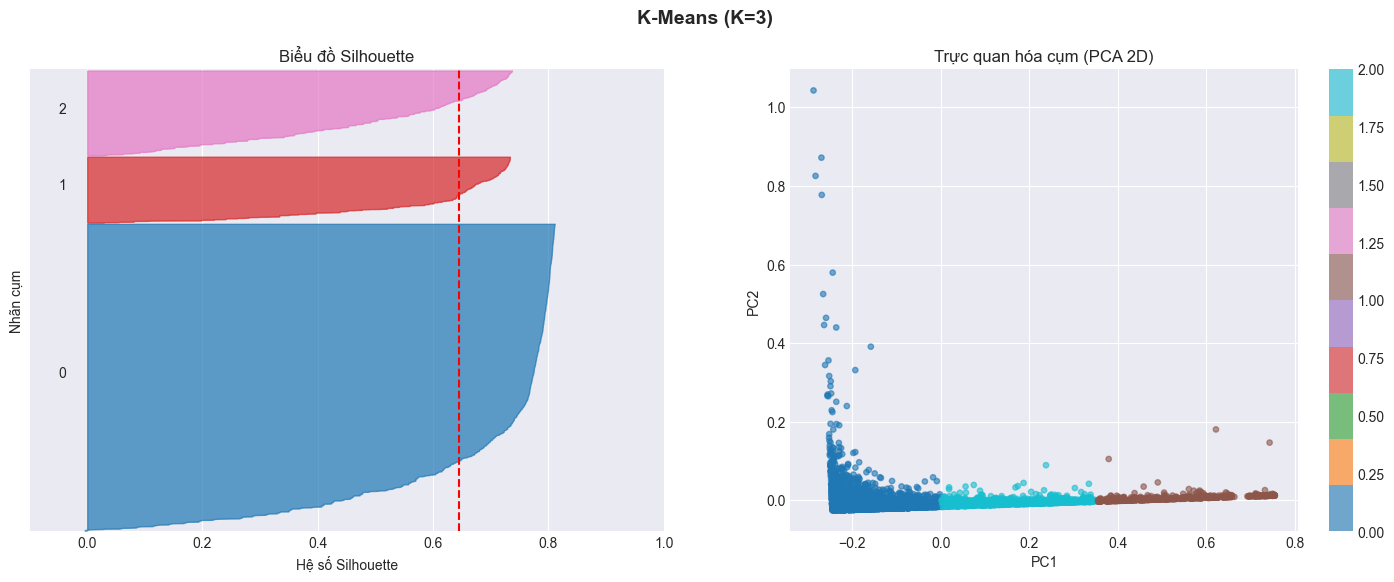

In [245]:
plot_silhouette(X_mm, km_labels, f"K-Means (K={K_OPTIMAL})")


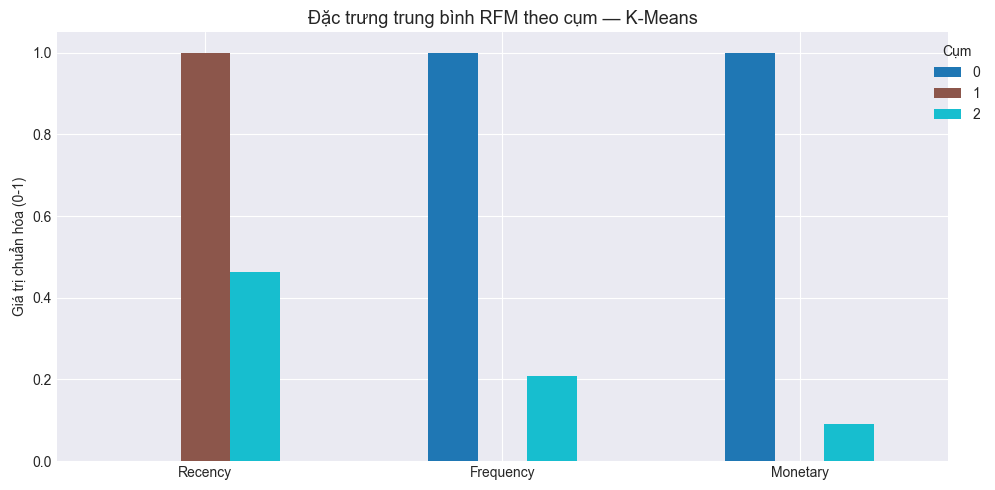


Giá trị RFM trung bình theo cụm:
         Recency  Frequency  Monetary
Cluster                              
0          32.16       5.47   2714.74
1         294.43       1.35    607.20
2         153.40       2.22    796.87


In [246]:
km_means = plot_rfm_clusters(rfm, km_labels, "K-Means")
print("\nGiá trị RFM trung bình theo cụm:")
print(km_means.round(2))

# 8. Agglomerative Hierarchical Clustering

**Agglomerative Clustering** là phương pháp từ dưới lên (bottom-up): ban đầu mỗi điểm là một cụm, sau đó gộp dần hai cụm gần nhau nhất, xây thành một cây phân cấp đầy đủ (dendrogram).

Khác với K-Means, số cụm K **không cần biết trước**: ta để thuật toán gộp hết thành 1 cây, rồi chọn điểm cắt (`distance_threshold`) dựa trên khoảng gãy (gap) lớn nhất giữa các lần gộp cuối cùng — đây là cách tự chọn K đúng bản chất của Agglomerative, thay vì ép K theo Elbow như K-Means.

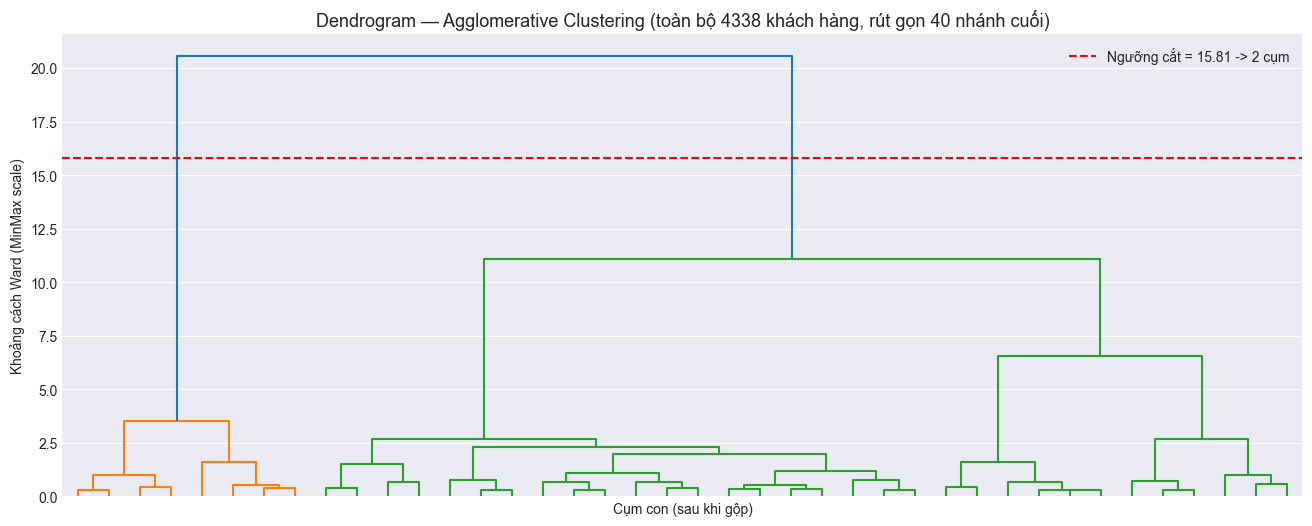

Ngưỡng cắt tự động (khoảng gãy lớn nhất giữa các lần gộp cuối) = 15.8055 -> 2 cụm


In [247]:
linked_full = shc.linkage(X_mm, method="ward")
merge_distances = np.sort(linked_full[:, 2])[::-1]

top_n = 10  # chỉ xét các lần gộp cuối cùng, tương ứng K trong khoảng 2-11
gaps = merge_distances[:top_n] - merge_distances[1:top_n + 1]
gap_idx = int(np.argmax(gaps))
threshold = (merge_distances[gap_idx] + merge_distances[gap_idx + 1]) / 2
AGG_CLUSTERS = gap_idx + 2

plt.figure(figsize=(16, 6))
shc.dendrogram(linked_full, no_labels=True, truncate_mode="lastp", p=40, color_threshold=threshold)
plt.axhline(y=threshold, color="red", linestyle="--",
            label=f"Ngưỡng cắt = {threshold:.2f} -> {AGG_CLUSTERS} cụm")
plt.title("Dendrogram — Agglomerative Clustering (toàn bộ 4338 khách hàng, rút gọn 40 nhánh cuối)", fontsize=13)
plt.xlabel("Cụm con (sau khi gộp)")
plt.ylabel("Khoảng cách Ward (MinMax scale)")
plt.legend()
plt.show()

print(f"Ngưỡng cắt tự động (khoảng gãy lớn nhất giữa các lần gộp cuối) = {threshold:.4f} -> {AGG_CLUSTERS} cụm")


In [ ]:
#  Tham khảo: K theo Elbow (kiểu K-Means, phải ép K) -
k_range = range(2, 11)
agg_sse = []
for k in k_range:
    lbl = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward").fit_predict(X_mm)
    sse_k = sum(((X_mm[lbl == c] - X_mm[lbl == c].mean(axis=0))**2).sum() for c in set(lbl))
    agg_sse.append(sse_k)

agg_sse_arr = np.array(agg_sse)
elbow_idx_agg = int(np.argmax(np.diff(np.diff(agg_sse_arr)))) + 1
K_ELBOW = list(k_range)[elbow_idx_agg]
print(f"[Tham khảo] K theo Elbow (ép K, giống K-Means): {K_ELBOW}")

# Chính thức: dùng threshold đã xác định từ dendrogram ở trên (không ép K)
print(f"[Chính thức] K tự chọn (distance_threshold = {threshold:.4f}): {AGG_CLUSTERS}")

agg = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, metric="euclidean", linkage="ward")
agg_labels = agg.fit_predict(X_mm)
rfm["Agg_Cluster"] = agg_labels

print_scores(agg_labels, X_mm, "Agglomerative")
print("\nSố khách hàng mỗi cụm:")
print(pd.Series(agg_labels).value_counts().sort_index())


[Tham khảo] K theo Elbow (ép K, giống K-Means): 3
[Chính thức] K tự chọn (distance_threshold = 15.8055): 2
[Agglomerative] Số cụm: 2 | Silhouette: 0.6755 | Davies-Bouldin: 0.3660

Số khách hàng mỗi cụm:
0    3733
1     605
Name: count, dtype: int64


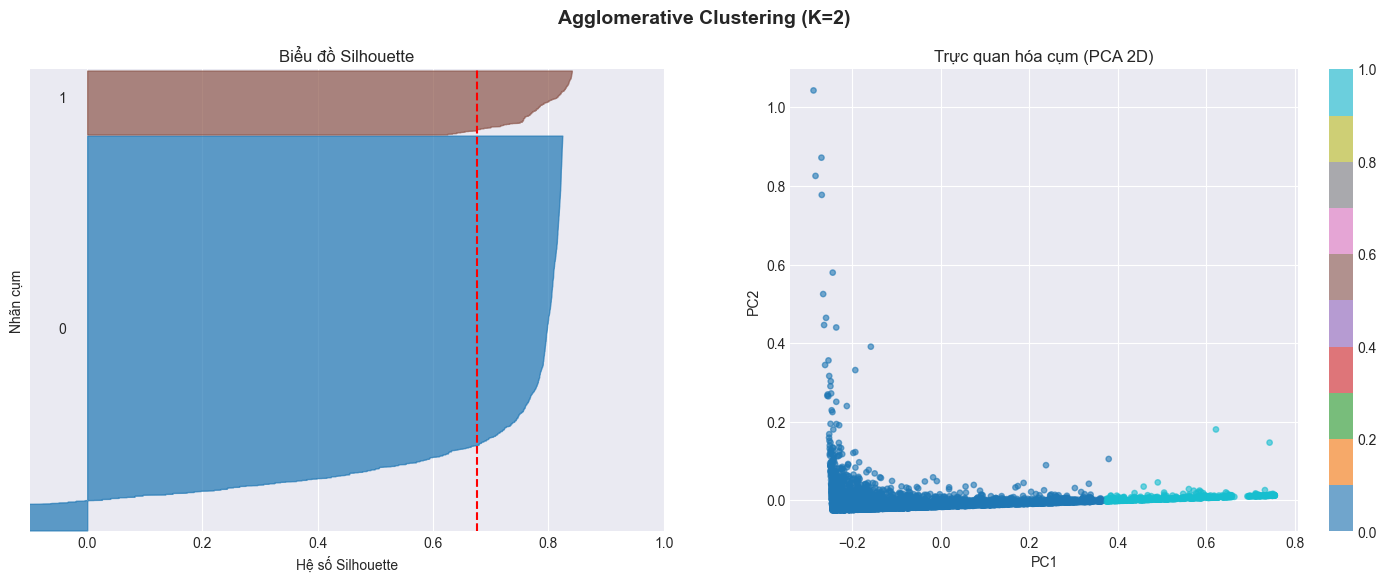

In [249]:
plot_silhouette(X_mm, agg_labels, f"Agglomerative Clustering (K={AGG_CLUSTERS})")


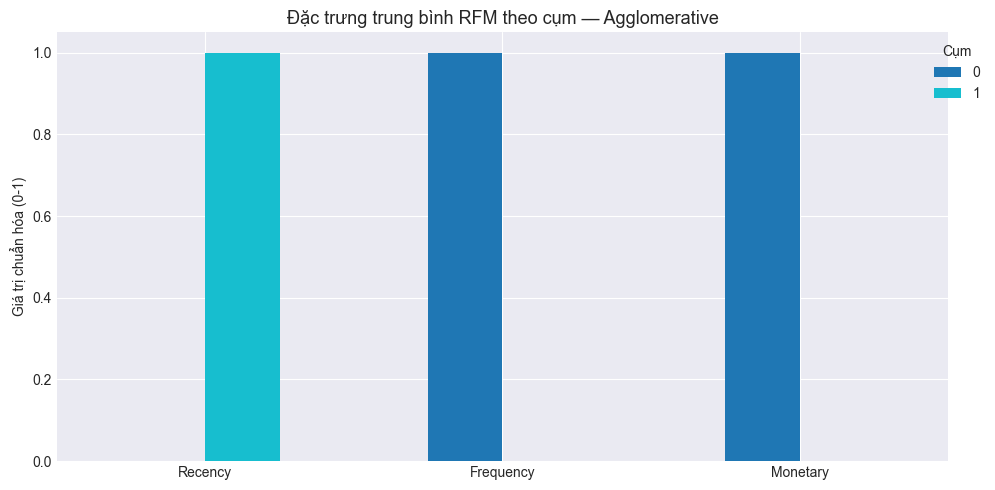


Giá trị RFM trung bình theo cụm:
         Recency  Frequency  Monetary
Cluster                              
0          59.44       4.74   2299.62
1         296.78       1.36    540.37

Mapping nhãn cụm Agglomerative: {0: 'Khách hoạt động', 1: 'Khách ít hoạt động'}


In [250]:
agg_means = plot_rfm_clusters(rfm, agg_labels, "Agglomerative")
print("\nGiá trị RFM trung bình theo cụm:")
print(agg_means.round(2))

AGG_NAMES = auto_name_clusters(rfm, "Agg_Cluster")
print(f"\nMapping nhãn cụm Agglomerative: {AGG_NAMES}")

# 9. DBSCAN

**DBSCAN** là thuật toán phân cụm dựa trên mật độ. Thay vì cần chỉ định số cụm, DBSCAN tự tìm các vùng dày đặc và đánh dấu các điểm nằm ở vùng thưa là **nhiễu (-1)**.

**Hai tham số chính:**
- `eps`: bán kính vùng lân cận
- `min_samples`: số điểm tối thiểu trong vùng lân cận để tạo thành điểm lõi

**Tìm eps tốt:** Dùng k-distance graph — tìm điểm "khuỷu tay" trên đồ thị.

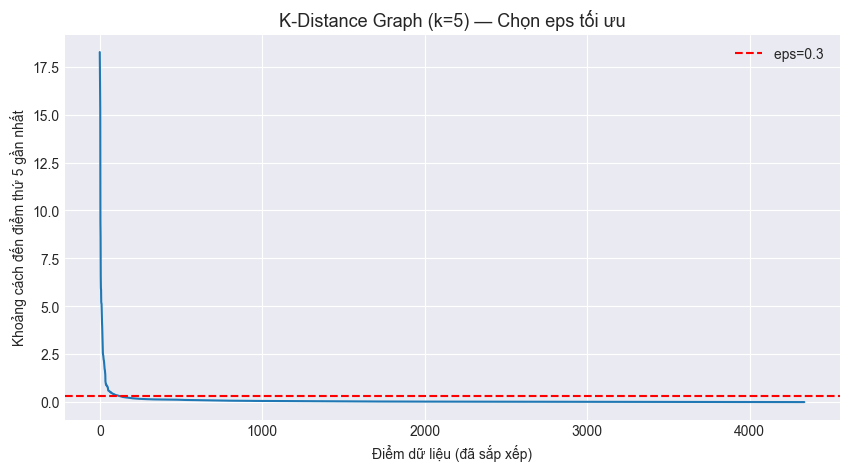

In [251]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_std)
distances, _ = nbrs.kneighbors(X_std)
distances = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-Distance Graph (k=5) — Chọn eps tối ưu", fontsize=13)
plt.xlabel("Điểm dữ liệu (đã sắp xếp)")
plt.ylabel("Khoảng cách đến điểm thứ 5 gần nhất")
plt.axhline(y=0.3, color="red", linestyle="--", label="eps=0.3 ")
plt.legend()
plt.show()


 eps  n_clusters  noise
0.10          26    471
0.15           6    226
0.20           3    161
0.25           2    130
0.30           2    107
0.35           2     84
0.40           1     73
0.45           2     62
0.50           1     54
0.55           1     49
0.60           1     46
0.65           1     46
0.70           1     45
0.75           1     44
0.80           1     41
0.85           1     34
0.90           1     33
0.95           1     33


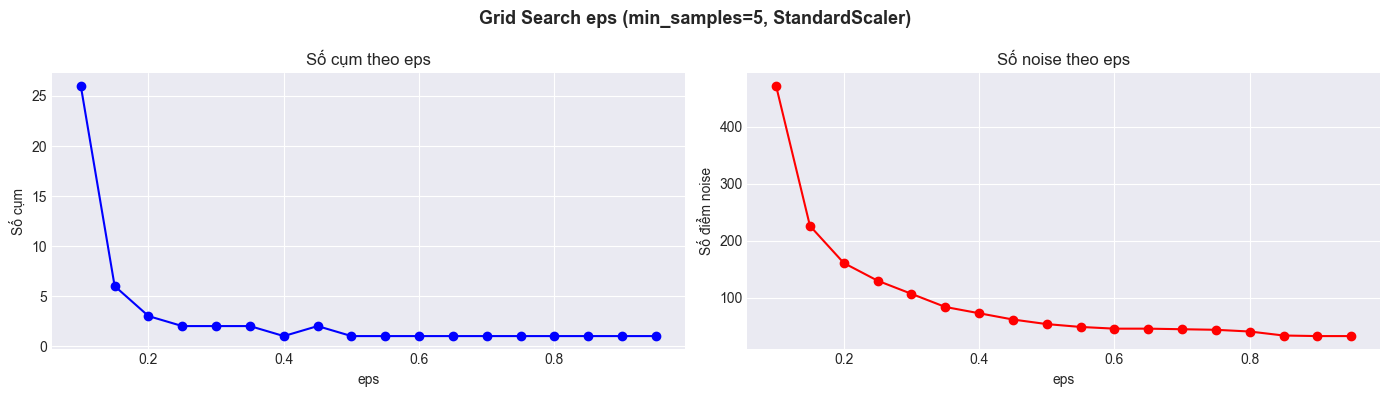


Eps=0.3 — Số cụm: 2, Noise: 107 (2.5%)
Phân bố nhãn: {-1: 107, 0: 4225, 1: 6}


In [252]:
from sklearn.neighbors import NearestNeighbors

eps_candidates = np.arange(0.1, 1.0, 0.05)
search_results = []
for e in eps_candidates:
    lbl = DBSCAN(eps=e, min_samples=5).fit_predict(X_std)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    search_results.append({"eps": round(e, 2), "n_clusters": n_c, "noise": n_noise})

sr = pd.DataFrame(search_results)
print(sr.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(sr["eps"], sr["n_clusters"], "bo-")
ax1.set_title("Số cụm theo eps"); ax1.set_xlabel("eps"); ax1.set_ylabel("Số cụm")
ax2.plot(sr["eps"], sr["noise"], "ro-")
ax2.set_title("Số noise theo eps"); ax2.set_xlabel("eps"); ax2.set_ylabel("Số điểm noise")
plt.suptitle("Grid Search eps (min_samples=5, StandardScaler)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

EPS = 0.3
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X_std)
rfm["DBSCAN_Cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"\nEps=0.3 — Số cụm: {n_clusters}, Noise: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print("Phân bố nhãn:", pd.Series(db_labels).value_counts().sort_index().to_dict())


[DBSCAN] Số cụm: 2 | Silhouette: 0.6743 | Davies-Bouldin: 0.2841


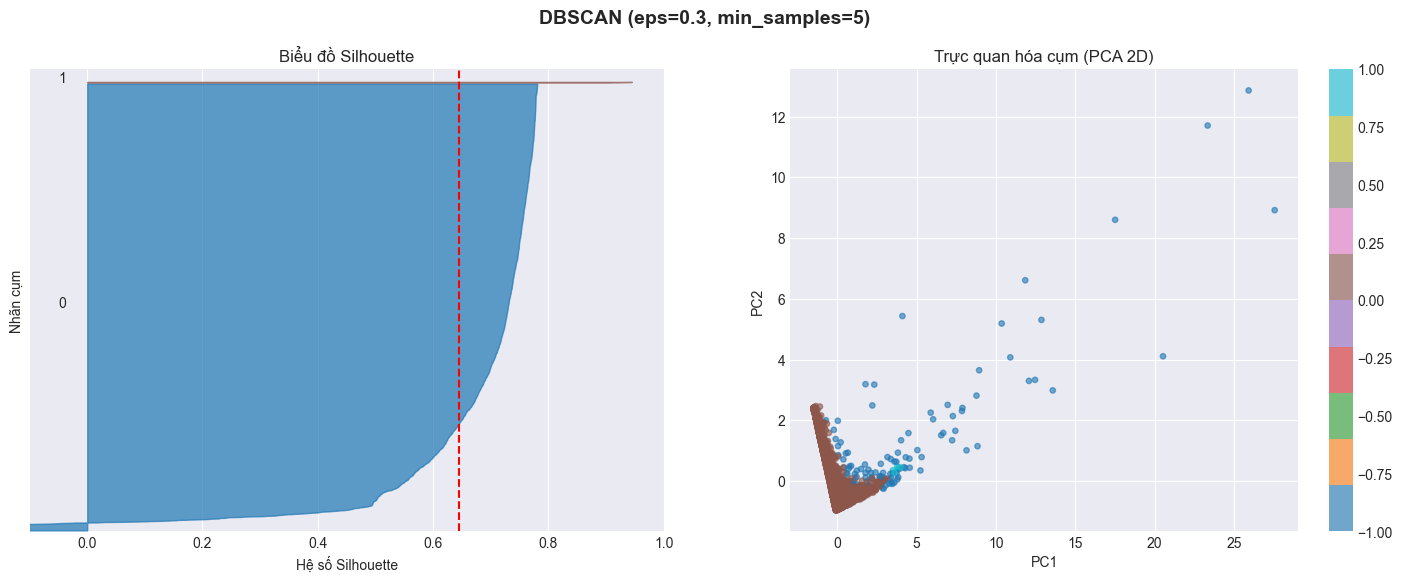

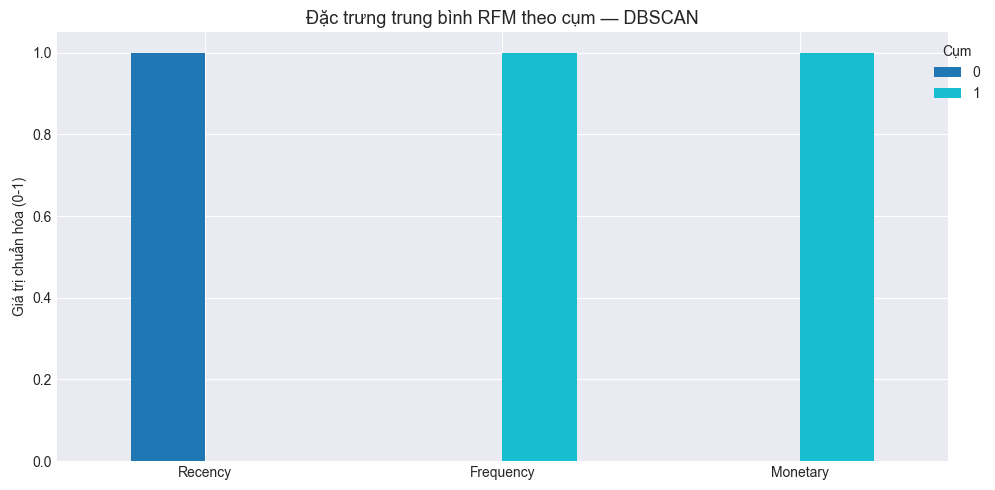


Mapping nhãn cụm DBSCAN: {0: 'Khách ít hoạt động', 1: 'Khách hoạt động', -1: 'Ngoại lệ (chi tiêu vượt trội)'}

Giá trị RFM trung bình theo nhãn DBSCAN (bao gồm nhiễu):
                Recency  Frequency  Monetary
DBSCAN_Cluster                              
-1                48.41      30.10  32218.07
 0                93.78       3.58   1266.49
 1                 4.17      29.67  18855.45

Nhận xét về nhóm nhiễu (-1): với eps/min_samples hiện tại, nhóm này KHÔNG phải
khách hàng bất thường theo nghĩa xấu -- Recency thấp, Frequency và Monetary còn
cao hơn cả cụm 'tốt nhất' tìm được. Đây là các khách chi tiêu/mua hàng vượt trội,
nằm rải rác ở vùng mật độ thưa trong không gian đã chuẩn hóa (StandardScaler bị
Monetary lệch mạnh kéo giãn), nên DBSCAN tách họ ra khỏi cụm chính thay vì gộp
thành một cụm mật độ riêng. Vì vậy tên gọi được suy ra tự động ở trên phản ánh
đúng bản chất là 'ngoại lệ chi tiêu vượt trội', không phải khách hàng cần loại bỏ.


In [253]:
if len(set(db_labels)) - (1 if -1 in db_labels else 0) >= 2:
    print_scores(db_labels, X_std, "DBSCAN")
    plot_silhouette(X_std, db_labels, f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})")
    plot_rfm_clusters(rfm, db_labels, "DBSCAN")
else:
    print("DBSCAN tìm được < 2 cụm. Hãy thử điều chỉnh eps và min_samples.")

DB_NAMES = auto_name_clusters(rfm, "DBSCAN_Cluster")
print(f"\nMapping nhãn cụm DBSCAN: {DB_NAMES}")

print("\nGiá trị RFM trung bình theo nhãn DBSCAN (bao gồm nhiễu):")
print(rfm.groupby("DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2))

print("\nNhận xét về nhóm nhiễu (-1): với eps/min_samples hiện tại, nhóm này KHÔNG phải")
print("khách hàng bất thường theo nghĩa xấu -- Recency thấp, Frequency và Monetary còn")
print("cao hơn cả cụm 'tốt nhất' tìm được. Đây là các khách chi tiêu/mua hàng vượt trội,")
print("nằm rải rác ở vùng mật độ thưa trong không gian đã chuẩn hóa (StandardScaler bị")
print("Monetary lệch mạnh kéo giãn), nên DBSCAN tách họ ra khỏi cụm chính thay vì gộp")
print("thành một cụm mật độ riêng. Vì vậy tên gọi được suy ra tự động ở trên phản ánh")
print("đúng bản chất là 'ngoại lệ chi tiêu vượt trội', không phải khách hàng cần loại bỏ.")


# 10. So Sánh Các Thuật Toán

Tổng hợp chỉ số đánh giá để so sánh ba thuật toán.

> **Lưu ý khi đọc bảng:** mỗi thuật toán tự chọn K theo đúng bản chất của nó (K-Means: Elbow ép K; Agglomerative: khoảng gãy lớn nhất trên dendrogram; DBSCAN: mật độ), nên số cụm không giống nhau (3 vs 2 vs 2) và **không thuật toán nào "thắng tuyệt đối"** chỉ vì Silhouette cao hơn. Ngoài ra, Silhouette của DBSCAN chỉ tính trên các điểm không bị đánh dấu nhiễu (cột "Nhiễu"), trong khi K-Means/Agglomerative tính trên toàn bộ 4338 khách hàng — loại bớt điểm khó phân cụm tự nhiên sẽ đẩy Silhouette lên cao hơn, nên đây không phải phép so sánh ngang hàng tuyệt đối.

In [254]:
results = []
for name, labels, Xeval in [
    ("K-Means",       km_labels,  X_mm),
    ("Agglomerative", agg_labels, X_mm),
    ("DBSCAN",        db_labels,  X_std),
]:
    valid_mask  = labels != -1
    valid_labels = labels[valid_mask]
    X_valid = Xeval[valid_mask]
    n_c = len(set(valid_labels))
    if n_c >= 2:
        sil   = silhouette_score(X_valid, valid_labels)
        db_idx = davies_bouldin_score(X_valid, valid_labels)
        noise  = (~valid_mask).sum()
    else:
        sil, db_idx, noise = None, None, (~valid_mask).sum()
    results.append({
        "Thuật toán":      name,
        "Chuẩn hóa":       "MinMaxScaler" if name != "DBSCAN" else "StandardScaler",
        "Số cụm":          n_c,
        "Silhouette ↑":   round(sil, 4)    if sil    is not None else None,
        "Davies-Bouldin ↓": round(db_idx, 4) if db_idx is not None else None,
        "Nhiễu":           int(noise),
    })

summary = pd.DataFrame(results).set_index("Thuật toán")
print(summary.to_string())


                    Chuẩn hóa  Số cụm  Silhouette ↑  Davies-Bouldin ↓  Nhiễu
Thuật toán                                                                  
K-Means          MinMaxScaler       3          0.64              0.51      0
Agglomerative    MinMaxScaler       2          0.68              0.37      0
DBSCAN         StandardScaler       2          0.67              0.28    107


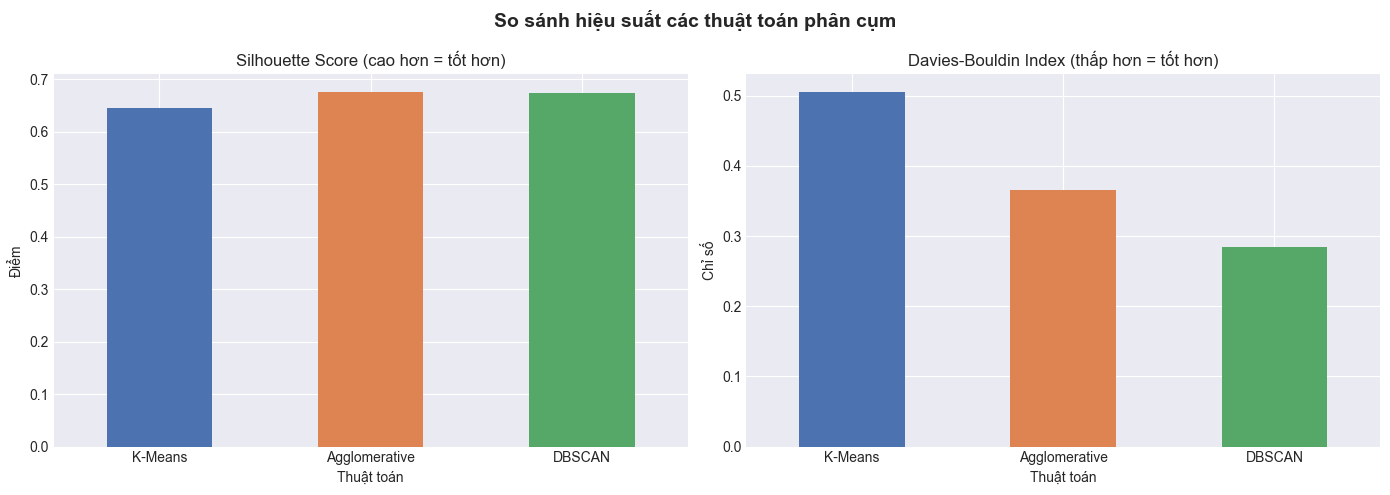

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_results = summary.dropna()
valid_results["Silhouette ↑"].plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452","#55A868"], rot=0)
axes[0].set_title("Silhouette Score (cao hơn = tốt hơn)")
axes[0].set_ylabel("Điểm")

valid_results["Davies-Bouldin ↓"].plot(kind="bar", ax=axes[1], color=["#4C72B0","#DD8452","#55A868"], rot=0)
axes[1].set_title("Davies-Bouldin Index (thấp hơn = tốt hơn)")
axes[1].set_ylabel("Chỉ số")

plt.suptitle("So sánh hiệu suất các thuật toán phân cụm", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 11. Phân Tích Phân Khúc Khách Hàng (K-Means)

Dùng kết quả K-Means (thường tốt nhất) để đặt tên và mô tả từng phân khúc.

In [256]:
seg = rfm.groupby("KMeans_Cluster")[["Recency","Frequency","Monetary"]].mean().round(1)
seg["Số KH"] = rfm.groupby("KMeans_Cluster").size()
seg["% KH"]  = (seg["Số KH"] / len(rfm) * 100).round(1)

# Gắn nhãn phân khúc dựa trên giá trị RFM
# Recency thấp + Frequency cao + Monetary cao → Khách VIP
print("Thống kê RFM theo cụm K-Means:")
print(seg.to_string())

# Gợi ý đặt tên (người dùng có thể thay đổi dựa trên giá trị thực tế)
print("\n💡 Gợi ý phân khúc:")
print("  Cụm có Recency thấp + Frequency cao + Monetary cao  → Khách VIP / Trung thành")
print("  Cụm có Recency thấp + Frequency thấp + Monetary thấp → Khách mới")
print("  Cụm có Recency cao  + Frequency thấp                 → Khách không hoạt động")
print("  Cụm có Recency trung bình + Monetary cao             → Khách tiềm năng")

Thống kê RFM theo cụm K-Means:
                Recency  Frequency  Monetary  Số KH  % KH
KMeans_Cluster                                           
0                 32.20       5.50   2714.70   2906 67.00
1                294.40       1.40    607.20    626 14.40
2                153.40       2.20    796.90    806 18.60

💡 Gợi ý phân khúc:
  Cụm có Recency thấp + Frequency cao + Monetary cao  → Khách VIP / Trung thành
  Cụm có Recency thấp + Frequency thấp + Monetary thấp → Khách mới
  Cụm có Recency cao  + Frequency thấp                 → Khách không hoạt động
  Cụm có Recency trung bình + Monetary cao             → Khách tiềm năng


In [257]:
# --- Đặt tên và bảng giải thích phân khúc K-Means ---
KMEANS_NAMES = auto_name_clusters(rfm, "KMeans_Cluster")

seg_display = seg.copy()
seg_display.index = seg_display.index.map(KMEANS_NAMES)
seg_display.index.name = "Phân khúc"
seg_display = seg_display.rename(columns={
    "Recency": "Recency TB (ngày)",
    "Frequency": "Frequency TB (đơn)",
    "Monetary": "Monetary TB (£)",
    "Số KH": "Số KH",
    "% KH": "% KH",
})

ly_do = {
    "Khách VIP":             "R rất thấp → mua rất gần đây  |  F & M cao nhất → thường xuyên & chi tiêu lớn",
    "Khách tiềm năng":       "R thấp → vẫn mua gần đây  |  F & M trung bình–thấp → chưa đủ gắn bó, cần phát triển",
    "Khách không hoạt động": "R cao → lâu không quay lại  |  F & M trung bình → từng có giá trị nhưng đang ngủ đông",
    "Khách rời bỏ":          "R rất cao → rất lâu không quay lại  |  F & M thấp nhất → nguy cơ mất vĩnh viễn",
    "Khách hoạt động":       "R thấp, F & M cao hơn trung bình",
    "Khách ít hoạt động":    "R cao, F & M thấp hơn trung bình",
}
seg_display["Lý do đặt tên"] = seg_display.index.map(
    lambda x: ly_do.get(x, "—")
)

chien_luoc = {
    "Khách VIP":             "Ưu tiên giữ chân: loyalty program, ưu đãi độc quyền",
    "Khách tiềm năng":       "Onboarding & nurturing: welcome offer, gợi ý sản phẩm phù hợp",
    "Khách không hoạt động": "Email/SMS tái kích hoạt, voucher có hạn sử dụng",
    "Khách rời bỏ":          "Win-back campaign hoặc chấp nhận mất — chi phí thu hút lại cao",
    "Khách hoạt động":       "Duy trì tương tác, upsell/cross-sell",
    "Khách ít hoạt động":    "Khảo sát lý do & chương trình kích hoạt lại",
}
seg_display["Chiến lược đề xuất"] = seg_display.index.map(
    lambda x: chien_luoc.get(x, "—")
)

print("=" * 90)
print("BẢNG PHÂN KHÚC KHÁCH HÀNG — K-MEANS")
print("=" * 90)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)
print(seg_display.to_string())
print("=" * 90)
print(f"Mapping nhãn cụm: {KMEANS_NAMES}")

BẢNG PHÂN KHÚC KHÁCH HÀNG — K-MEANS
                 Recency TB (ngày)  Frequency TB (đơn)  Monetary TB (£)  Số KH  % KH                                                                        Lý do đặt tên                                              Chiến lược đề xuất
Phân khúc                                                                                                                                                                                                                                
Khách VIP                    32.20                5.50          2714.70   2906 67.00        R rất thấp → mua rất gần đây  |  F & M cao nhất → thường xuyên & chi tiêu lớn             Ưu tiên giữ chân: loyalty program, ưu đãi độc quyền
Khách rời bỏ                294.40                1.40           607.20    626 14.40       R rất cao → rất lâu không quay lại  |  F & M thấp nhất → nguy cơ mất vĩnh viễn  Win-back campaign hoặc chấp nhận mất — chi phí thu hút lại cao
Khách tiềm năng             

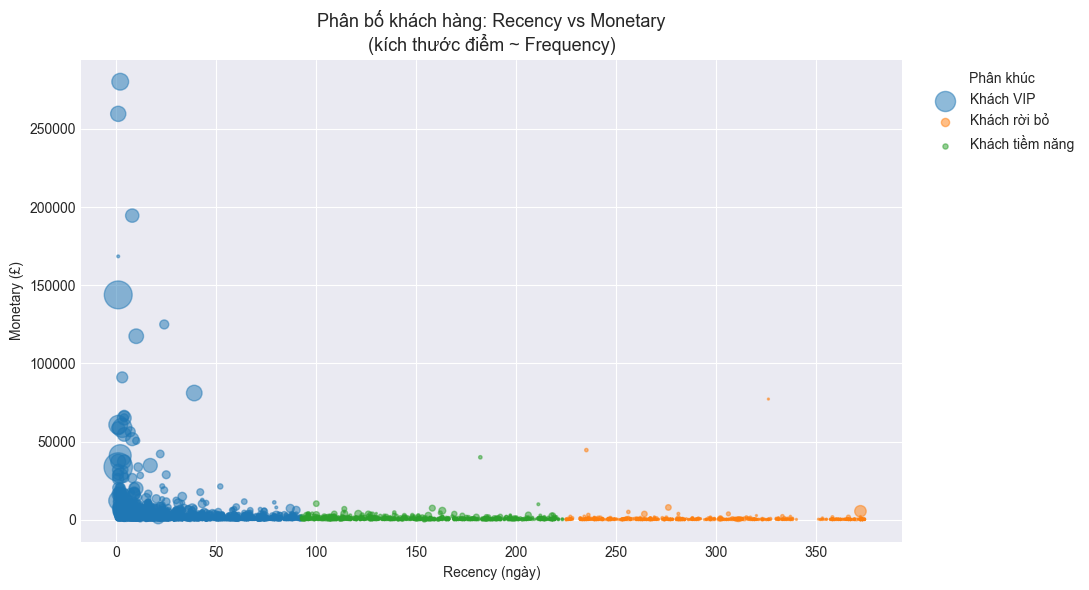

In [258]:
fig, ax = plt.subplots(figsize=(11, 6))
for cluster_id, cluster_name in KMEANS_NAMES.items():
    mask = rfm["KMeans_Cluster"] == cluster_id
    ax.scatter(
        rfm.loc[mask, "Recency"],
        rfm.loc[mask, "Monetary"],
        label=cluster_name,
        s=rfm.loc[mask, "Frequency"] * 2,
        alpha=0.5,
        color=PALETTE[cluster_id % len(PALETTE)],
    )
ax.set_xlabel("Recency (ngày)")
ax.set_ylabel("Monetary (£)")
ax.set_title("Phân bố khách hàng: Recency vs Monetary\n(kích thước điểm ~ Frequency)", fontsize=13)
ax.legend(title="Phân khúc", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 12. Kết Luận

>Thực nghiệm phân khúc khách hàng trên tập dữ liệu **Online Retail** với ba thuật toán:

| Thuật toán | Ưu điểm | Nhược điểm |
|------------|---------|------------|
| **K-Means** | Nhanh, cho cụm đều, dễ giải thích | Cần biết trước K, nhạy với ngoại lệ |
| **Agglomerative** | Không cần K trước, dendrogram trực quan | Chậm với dữ liệu lớn |
| **DBSCAN** | Tự tìm K, xử lý nhiễu tốt | Khó chọn eps, kém với mật độ không đều |

>**Nhận xét:** Ba thuật toán dùng ba tiêu chí chọn K khác nhau (K-Means: Elbow ép K; Agglomerative: tự chọn theo khoảng gãy lớn nhất trên dendrogram; DBSCAN: tự phát hiện qua mật độ) nên số cụm và điểm Silhouette giữa chúng không nhất thiết giống nhau — xem bảng số liệu ở Section 10 để so sánh cụ thể.
>
>**Nhãn phân khúc chỉ có ý nghĩa tương đối trong nội bộ từng thuật toán.** Vì K-Means chia 3 cụm còn Agglomerative chỉ chia 2, cụm "Khách rời bỏ" (K-Means) và cụm "Khách ít hoạt động" (Agglomerative) có thể trỏ tới cùng một nhóm khách hàng có Recency ~295 ngày, Frequency ~1.4 đơn — khác nhau chỉ vì số cụm bị chia khác nhau, không phải vì bản chất khách hàng khác nhau.
>
>**Nhóm "nhiễu" của DBSCAN không đại diện cho khách hàng bất thường theo nghĩa xấu.** Với eps=0.3, min_samples=5, 107 khách hàng bị đánh dấu nhiễu thực chất có Recency thấp và Frequency, Monetary **cao hơn** cả cụm tốt nhất DBSCAN tìm được (khách chi tiêu vượt trội / whale) — họ chỉ nằm ở vùng mật độ thưa do Monetary lệch mạnh sau chuẩn hóa, nên bị tách khỏi cụm chính. Đây là hạn chế của DBSCAN trên dữ liệu RFM có phân phối lệch (skewed), không phải phát hiện gian lận/bất thường thật sự.

# 13. Biểu đồ 2D Kết quả Phân Cụm (từng cặp RFM)

Trực quan hóa ba cặp: **Recency × Frequency**, **Recency × Monetary**, **Frequency × Monetary** cho cả ba thuật toán.

In [259]:
def plot_2d_pairs(rfm_df, labels, title, name_map=None):
    """Vẽ 3 scatter 2D theo từng cặp RFM, tô màu theo cụm."""
    pairs = [("Recency", "Frequency"), ("Recency", "Monetary"), ("Frequency", "Monetary")]
    unique_labels = sorted(set(labels))
    color_map = {lbl: PALETTE[i % len(PALETTE)] for i, lbl in enumerate(l for l in unique_labels if l != -1)}
    if -1 in unique_labels:
        color_map[-1] = "lightgray"

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, (xcol, ycol) in zip(axes, pairs):
        for lbl in unique_labels:
            mask = labels == lbl
            display_name = (name_map[int(lbl)] if (name_map and int(lbl) in name_map) else
                            ("Ngoại lệ" if lbl == -1 else f"Cụm {lbl}"))
            ax.scatter(
                rfm_df.loc[mask, xcol],
                rfm_df.loc[mask, ycol],
                label=display_name,
                color=color_map[lbl],
                alpha=0.45, s=12,
                zorder=(1 if lbl == -1 else 2),
            )
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        ax.set_title(f"{xcol} vs {ycol}")
        ax.legend(title="Phân khúc", fontsize=8, markerscale=2)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Hàm plot_2d_pairs đã sẵn sàng!")

Hàm plot_2d_pairs đã sẵn sàng!


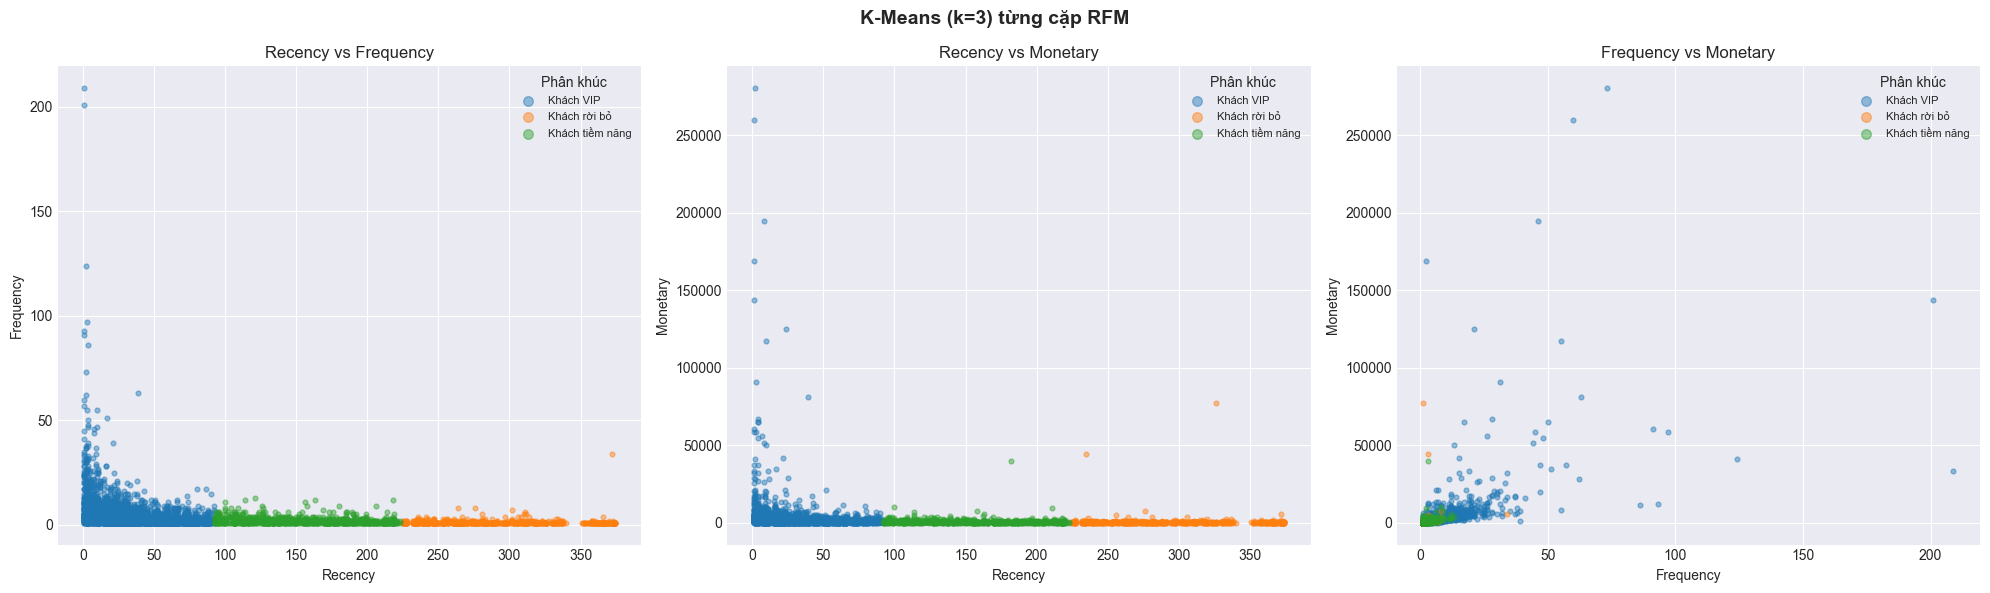

In [260]:
plot_2d_pairs(
    rfm,
    km_labels,
    f"K-Means (k={K_OPTIMAL}) từng cặp RFM",
    name_map=KMEANS_NAMES,
)

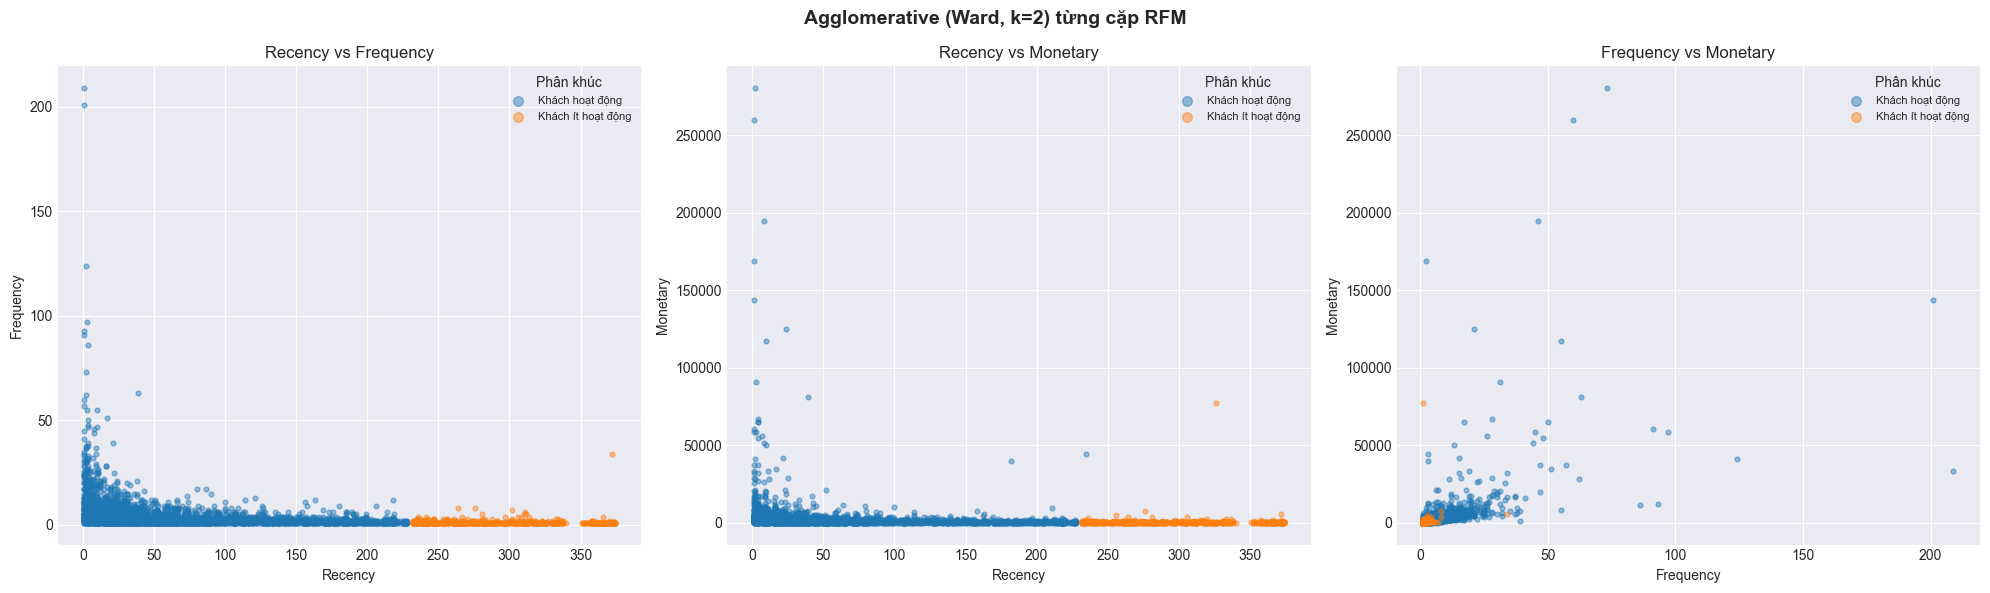

In [261]:
plot_2d_pairs(
    rfm,
    agg_labels,
    f"Agglomerative (Ward, k={AGG_CLUSTERS}) từng cặp RFM",
    name_map=AGG_NAMES,
)

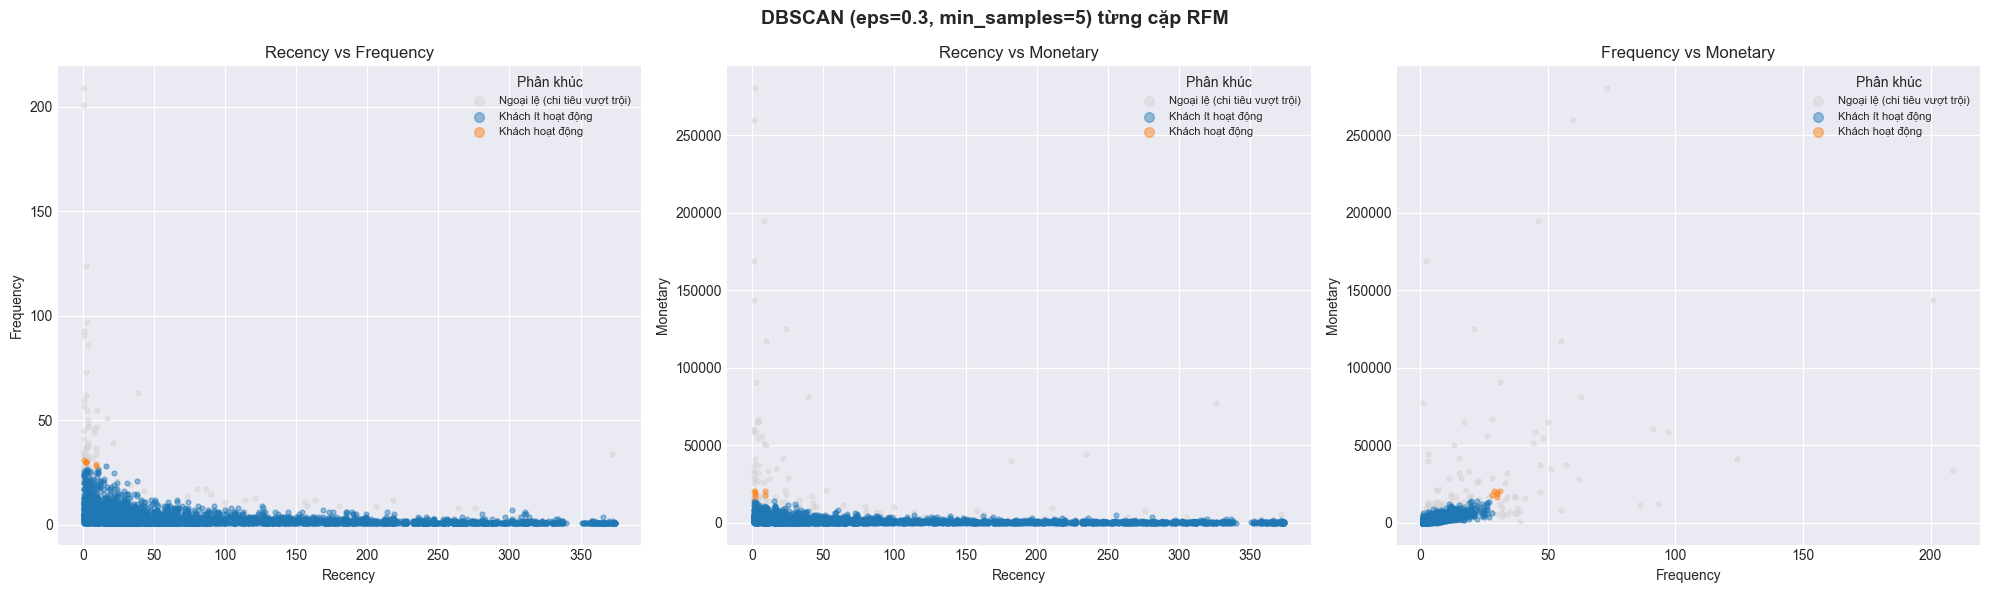

In [262]:
plot_2d_pairs(
    rfm,
    db_labels,
    f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) từng cặp RFM",
    name_map=DB_NAMES,
)